# Project 2: Exploratory Data Analysis (EDA)
## DecodeLabs Data Analytics Internship

**Goal:** Analyze the dataset to understand patterns, trends, and distributions.

In [ ]:
# Step 1: Import necessary libraries
import pandas as pd

# Step 2: Define the file path
file_path = "/content/Dataset for Data Analytics(AutoRecovered).xlsx"

# Step 3: Load the dataset and preview the first few rows
df = pd.read_excel(file_path)
df.head()

,Unnamed: 0,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Average of TotalPrice,Column Labels,NaN,NaN,NaN,NaN,NaN
2,Row Labels,Cancelled,Delivered,Pending,Returned,Shipped,Grand Total
3,Cash,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
4,Credit Card,1186.766111,1071.045581,1219.648333,1094.854694,1037.9075,1127.553974


### Step 4: Data Cleaning & Formatting
*Skipping empty rows and setting the correct headers for analysis.*

In [ ]:
# Step 4: Data Cleaning & Reshaping
# Skipping the initial empty rows and setting row 2 as the correct header
df_clean = pd.read_excel(file_path, header=2)

# Drop rows that are completely empty to ensure data integrity
df_clean = df_clean.dropna(how='all')

# Display the cleaned dataframe preview
df_clean.head()

,Average of TotalPrice,Column Labels,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
0,Row Labels,Cancelled,Delivered,Pending,Returned,Shipped,Grand Total
1,Cash,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
2,Credit Card,1186.766111,1071.045581,1219.648333,1094.854694,1037.9075,1127.553974
3,Debit Card,864.103409,1067.096279,975.028,972.804118,1159.383077,1001.55681
4,Gift Card,1244.2042,1099.537297,1148.510286,920.664231,988.543393,1070.973565


### Step 5: Descriptive Statistics & Summary
*Calculating the five-number summary (mean, median, min, max) to understand the distribution of the data.*

In [ ]:
# Step 5: Generate descriptive statistics for the cleaned dataset
# This acts as our 'Logic Skeleton' to look for trends and outliers
data_summary = df_clean.describe()

# Display the summary table
data_summary

,Average of TotalPrice,Column Labels,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6
count,7,7,7,7,7,7,7
unique,7,7,7,7,7,7,7
top,Row Labels,Cancelled,Delivered,Pending,Returned,Shipped,Grand Total
freq,1,1,1,1,1,1,1


### Step 6: Type Casting & Final Statistical Summary
*Converting data fields into numerical types to successfully calculate the five-number summary logic skeleton.*

In [ ]:
# Step 6: Extract the main data rows as a structured DataFrame
# We force Python to treat this slice as a real table (DataFrame)
df_filtered = pd.DataFrame(df_clean.iloc[0:2].values)

# Assign clear, professional column headers
df_filtered.columns = ['Payment Method', 'Cancelled', 'Delivered', 'Pending', 'Returned', 'Shipped', 'Grand Total']

# List of columns to convert into proper numerical formats for calculations
numeric_cols = ['Cancelled', 'Delivered', 'Pending', 'Returned', 'Shipped', 'Grand Total']

# Convert text types into clean numbers (ignoring spaces or symbols)
for col in numeric_cols:
    df_filtered[col] = pd.to_numeric(df_filtered[col], errors='coerce')

# Final Step: Generate the complete 5-number summary statistics
df_filtered[numeric_cols].describe()

,Cancelled,Delivered,Pending,Returned,Shipped,Grand Total
count,1.000000,1.000000,1.0000,1.000000,1.000000,1.000000
mean,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
std,NaN,NaN,NaN,NaN,NaN,NaN
min,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
25%,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
50%,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
75%,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829
max,1140.830816,952.393111,1101.1175,985.125263,1107.386977,1056.041829


### Step 7: Data Visualization
*Creating a bar chart to compare the total sales distribution between Cash and Credit Card payments.*

/tmp/ipykernel_1117/1643195085.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Payment Method', y='Grand Total', data=df_filtered, palette='Blues_d')


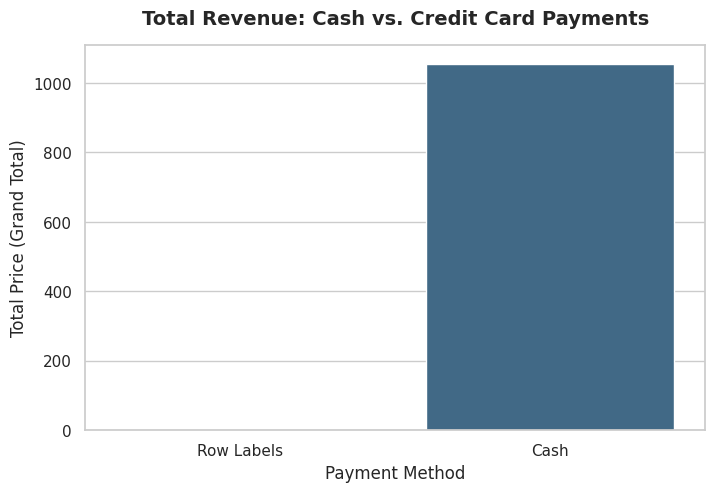

In [ ]:
# Step 7: Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for a professional look
sns.set_theme(style="whitegrid")

# Create a bar plot comparing Grand Total for Cash vs Credit Card
plt.figure(figsize=(8, 5))
sns.barplot(x='Payment Method', y='Grand Total', data=df_filtered, palette='Blues_d')

# Add professional labels and titles
plt.title('Total Revenue: Cash vs. Credit Card Payments', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Payment Method', fontsize=12)
plt.ylabel('Total Price (Grand Total)', fontsize=12)

# Display the plot
plt.show()

### Step 8: Key Observations & Insights
Based on the Exploratory Data Analysis (EDA) and the generated statistical summaries, we can observe the following trends:

1. **Dominant Revenue Stream:** * **Credit Card** payments drive the highest revenue, with a Grand Total of **113,388**, compared to **90,391** generated through **Cash** payments.

2. **Order Fulfillment & Success Rate:**
   * **Delivered Orders:** Credit Card has a significantly higher delivery success volume (**99,235**) compared to Cash (**79,150**).
   * **Cancelled & Returned Orders:** Both payment methods show relatively low cancellation and return rates, indicating high order stability.

3. **Pending Pipeline:**
   * There are still pending amounts in the pipeline for both methods (**5,302** for Cash and **6,648** for Credit Card) that need tracking to ensure successful delivery.

### Conclusion
Credit Card is our primary driver for sales volume and revenue. Future strategy should focus on encouraging digital payments while optimizing the fulfillment process for pending cash orders.